In [200]:
import pandas as pd
import geopandas as gpd
import openpyxl
from shapely.geometry import Point
import json
import folium
import plotly.express as px
import locale # Para formatação de moeda em padrões regionais

geral = pd.read_excel('Geral.xlsx', sheet_name='Tabela Geral')
# geral['Ano'] = geral['Ano'].astype(int)
# geral['Processo SEI'] = geral['Processo SEI'].astype(int)

geral.rename(columns={'Coordenada X': 'lon', 'Coordenada Y': 'lat', 'Unidade': 'Secretaria', 'Equipamento 1': 'Tipo Equipamento', 'Equipamento 2': 'Sub Tipo Equipamento'}, inplace=True)
dadosgeo = geral
dadosgeo['lon'] = pd.to_numeric(geral['lon'], errors='coerce')
dadosgeo['lat'] = pd.to_numeric(geral['lat'], errors='coerce')
dadosgeo = geral.dropna(subset=['lon', 'lat'])

geometry = [Point(xy) for xy in zip(dadosgeo["lon"], dadosgeo["lat"])]
pontos = gpd.GeoDataFrame(dadosgeo, geometry=geometry)
#pontos.drop(columns=['lon', 'lat'], inplace=True)
pontos.set_crs(epsg=4326, inplace=True)
print(pontos.crs)

EPSG:4326


In [201]:
#Importa a s geometrias das subprefeituras e distritos, mas apenas as colunas necessárias: nome e polígono
subs = gpd.read_file('subprefeituras.geojson', encoding='utf-8')[['nm_subprefeitura','geometry']]
subs = subs.rename(columns={'nm_subprefeitura':'SubPrefeitura'})
distritos = gpd.read_file('EPSG4326-DistritosSP.geojson', encoding='utf-8')[['nm_distrito_municipal', 'geometry']]
distritos = distritos.rename(columns={'nm_distrito_municipal':'Distrito'})


In [202]:
ipvs = gpd.read_file('IPVS.geojson', encoding='utf-8')[['cd_indice_vulnerabilidade_social', 'geometry']]
ipvs.rename(columns={'cd_indice_vulnerabilidade_social': 'IPVS'}, inplace=True)
mapeamento = {
    0.0: 'Sem Classificação',
    1.0: '1- Baixíssima vulnerabilidade',
    2.0: '2- Vulnerabilidade muito baixa',
    3.0: '3- Vulnerabilidade baixa',
    4.0: '4- Vulnerabilidade média',
    5.0: '5- Vulnerabilidade alta (urbanos)',
    6.0: '6- Vulnerabilidade muito alta (aglomerados subnormais urbanos)',
    7.0: '7- Vulnerabilidade alta (rurais)'
}

ipvs['Vulnerabilidade'] = ipvs['IPVS'].map(mapeamento)

In [203]:
pontos = gpd.sjoin(pontos, subs, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos = gpd.sjoin(pontos, distritos, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos = gpd.sjoin(pontos, ipvs, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos.columns

Index(['Ano', 'Nota Empenho', 'Nota Reserva', 'Ata CMDP', 'Processo SEI',
       'Secretaria', 'Função', 'Sub Função', 'Programa', 'Atividade',
       'Sub Elemento Despesa', 'Item Despesa', 'Observação Empenho',
       'Contrato', 'Credor Nome', 'Valor Empenho', 'Valor Empenho Cancelado',
       'Valor Empenho Líquido', 'Valor Empenho Liquidado',
       'Valor Empenho Pago', 'Tipo Equipamento', 'Sub Tipo Equipamento',
       'Endereço', 'Região', 'Extensão (m)', 'Trecho (Recap)', 'lat', 'lon',
       'geometry', 'SubPrefeitura', 'Distrito', 'IPVS', 'Vulnerabilidade'],
      dtype='object')

In [204]:
PMD = gpd.read_file('PMD-WFS.geojson', encoding='utf-8')
PMD
# ipvs.rename(columns={'cd_indice_vulnerabilidade_social': 'IPVS'}, inplace=True)

,cd_identificador_concessao,cd_identificador_equipamento,nm_equipamento,nm_parceria,tx_modalidade_concessao,qt_prazo_concessao,nm_concessionaria,tx_cnpj_concessionaria,tx_poder_concedente,an_assinatura,qt_area_metro,tx_numero_contrato,qt_investimento_real,tx_link_contrato,dt_atualizacao,cd_usuario_atualizacao,geometry
0,1,28.0,Cemitério São Paulo,Cemitérios - Bloco 2,Concessão,25.0,SPE CONSÓRCIO CORTEL SP S/A,47.701.152/0001-85,São Paulo Regula,2022,104764.86,CONTRATO DE CONCESSÃO Nº 54/SFMSP/2022,6253000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.68729 -23.55848, -46.68728..."
1,2,30.0,Cemitério da Consolção,Cemitérios - Bloco 1,Concessão,25.0,CONCESSIONÁRIA DE CEMITÉRIOS E SERVIÇOS FUNERÁ...,47.863.166/0001-03,São Paulo Regula,2022,69704.94,CONTRATO DE CONCESSÃO Nº 53/SFMSP/2022,6492000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.6595 -23.5509, -46.65876 -..."
2,3,29.0,Cemitério do Araçá,Cemitérios - Bloco 2,Concessão,25.0,SPE CONSÓRCIO CORTEL SP S/A,47.701.152/0001-85,São Paulo Regula,2022,222160.66,CONTRATO DE CONCESSÃO Nº 54/SFMSP/2022,11641000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.67539 -23.55131, -46.67457..."
3,4,27.0,Parque do Ibirapuera,1º Lote de Parques,Concessão,35.0,URBIA GESTÃO DE PARQUES SPE S.A.,35.814.889/0001-25,Secretaria municipal do Verde e Meio Ambiente,2019,1122644.73,CONTRATO DE CONCESSÃO N.º 057/SVMA/2019,91900000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.6633 -23.58224, -46.66321 ..."
4,5,17.0,Cemitério da Vila Mariana,Cemitérios - Bloco 1,Concessão,25.0,CONCESSIONÁRIA DE CEMITÉRIOS E SERVIÇOS FUNERÁ...,44.615.216/0001-37,São Paulo Regula,2022,63695.77,CONTRATO DE CONCESSÃO Nº 53/SFMSP/2022,9729000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.62861 -23.58134, -46.6285 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,90,4.0,Vale do Anhangabaú,Vale do Anhangabaú,Concessão,10.0,VIVA O VALE CONCESSIONÁRIA SPE S.A.,42.571.468/0001-86,Secretaria Muncipal de Subprefeituras,2021,61936.16,CONTRATO DE CONCESSÃO N.º 018/SUB-SÉ/2021,6542000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.63777 -23.54768, -46.63772..."
90,91,4.0,Vale do Anhangabaú,Vale do Anhangabaú,Concessão,10.0,VIVA O VALE CONCESSIONÁRIA SPE S.A.,42.571.468/0001-86,Secretaria Muncipal de Subprefeituras,2021,1635.60,CONTRATO DE CONCESSÃO N.º 018/SUB-SÉ/2021,6542000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.63488 -23.54558, -46.63489..."
91,92,4.0,Vale do Anhangabaú,Vale do Anhangabaú,Concessão,10.0,VIVA O VALE CONCESSIONÁRIA SPE S.A.,42.571.468/0001-86,Secretaria Muncipal de Subprefeituras,2021,3357.96,CONTRATO DE CONCESSÃO N.º 018/SUB-SÉ/2021,6542000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.63489 -23.54257, -46.63504..."
92,93,4.0,Vale do Anhangabaú,Vale do Anhangabaú,Concessão,10.0,VIVA O VALE CONCESSIONÁRIA SPE S.A.,42.571.468/0001-86,Secretaria Muncipal de Subprefeituras,2021,772.71,CONTRATO DE CONCESSÃO N.º 018/SUB-SÉ/2021,6542000.0,https://www.prefeitura.sp.gov.br/cidade/secret...,2024-05-28,None,"MULTIPOLYGON (((-46.63605 -23.54301, -46.636 -..."


In [205]:
PMD.explore(tiles='CartoDB positron')

In [206]:
#Somatória de investimento em Bilhões de reais
PMD['qt_investimento_real'].sum()/1000000000



np.float64(1.15652568)

In [207]:
#Somatória de áreas
PMD['qt_area_metro'].sum() / 1000000  # Área total em km²

np.float64(5.23917325)

In [208]:
PMD['tx_modalidade_concessao'].value_counts()

tx_modalidade_concessao
Concessão                          64
Parceria público-privada (PPP)     25
Termo de permissão de uso (TPU)     5
Name: count, dtype: int64

In [209]:
# #iloc aqui isola a sub
# print(type(subs.iloc[0].geometry))
# print(subs.iloc[0].nm_subprefeitura)
# subs.iloc[0].geometry

In [210]:
# pontos.geometry

In [211]:
# subs.iloc[i].geometry.intersects(pontos.geometry).value_counts().get(True, 0)

In [212]:
# soma =0
# for i in range(len(subs)):
#     a = subs.iloc[i].geometry.intersects(pontos.geometry).value_counts().get(True, 0)
#     soma = soma + a
#     print(a,soma)

In [213]:
pontos = gpd.sjoin(pontos, subs, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos = gpd.sjoin(pontos, distritos, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 537 entries, 0 to 1485
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Ano                      535 non-null    float64 
 1   Nota Empenho             535 non-null    object  
 2   Nota Reserva             535 non-null    object  
 3   Ata CMDP                 313 non-null    object  
 4   Processo SEI             535 non-null    float64 
 5   Secretaria               535 non-null    object  
 6   Função                   535 non-null    object  
 7   Sub Função               535 non-null    object  
 8   Programa                 535 non-null    object  
 9   Atividade                535 non-null    object  
 10  Sub Elemento Despesa     535 non-null    object  
 11  Item Despesa             535 non-null    object  
 12  Observação Empenho       535 non-null    object  
 13  Contrato                 533 non-null    object  
 14  Credor

In [214]:
# pontos['Ano'] = pontos['Ano'].astype(int)

pontos['Ano'] = pontos['Ano'].astype('Int64')
pontos['Ano'].value_counts()

Ano
2023    186
2020    179
2024     80
2022     41
2021     39
2019     10
Name: count, dtype: Int64

In [215]:
pontos['Processo SEI'] = pontos['Processo SEI'].astype('Int64').astype('string')

In [216]:
geral['Ano'] = geral['Ano'].astype('Int64')
geral['Processo SEI'] = geral['Processo SEI'].astype('Int64').astype('string')

In [217]:
def formatar_processo_sei(numero):
    if pd.isna(numero):
        return None
    numero = numero.zfill(16)  # Garante 16 dígitos, caso necessário (ajuste conforme o padrão real)
    return f"{numero[:4]}.{numero[4:8]}/{numero[8:15]}-{numero[15:]}"

In [218]:
pontos['Processo SEI'] = pontos['Processo SEI'].apply(formatar_processo_sei)


In [219]:
import numpy as np

# Normalizar valores de 'Valor Empenho' para o intervalo [5, 20]
min_radius, max_radius = 5, 20
min_valor = pontos['Valor Empenho'].min()
max_valor = pontos['Valor Empenho'].max()

pontos['radius'] = pontos['Valor Empenho'].apply(lambda x: min_radius + (max_radius - min_radius) * (x - min_valor) / (max_valor - min_valor))


In [220]:
# import folium

# # Inicializar o mapa
# m = folium.Map(location=[pontos.geometry.y.mean(), pontos.geometry.x.mean()],
#                zoom_start=11,
#                tiles='CartoDB positron')

# # Adicionar pontos com raio variável
# for idx, row in pontos.iterrows():
#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x],
#         radius=row['radius'],
#         color='black',
#         fill=True,
#         fill_color='red',
#         fill_opacity=0.8,
#         popup=folium.Popup(f"""
#             <b>Ano:</b> {row['Ano']}<br>
#             <b>Processo SEI:</b> {row['Processo SEI']}<br>
#             <b>Secretaria:</b> {row['Secretaria']}<br>
#             <b>Tipo Equipamento:</b> {row['Tipo Equipamento']}<br>
#             <b>Sub Tipo Equipamento:</b> {row['Sub Tipo Equipamento']}<br>
#             <b>Trecho (Recap):</b> {row['Trecho (Recap)']}<br>
#             <b>Valor Empenho:</b> R$ {row['Valor Empenho']:,.2f}
#         """, max_width=300)
#     ).add_to(m)

# # Exibir o mapa
# m


In [221]:
import matplotlib.pyplot as plt

# Definir valores únicos (exemplo com Ano)
valores_unicos = pontos['Ano'].dropna().unique()

# Gerar cores usando colormap do Matplotlib
colormap = plt.cm.get_cmap('tab10', len(valores_unicos))  # 'tab10', 'tab20', etc.

# Criar dicionário {Ano: cor_hex}
cores_por_ano = {ano: f'#{int(colormap(i)[0]*255):02x}{int(colormap(i)[1]*255):02x}{int(colormap(i)[2]*255):02x}'
                 for i, ano in enumerate(valores_unicos)}

# Exemplo de dicionário:
# {2020: '#1f77b4', 2021: '#ff7f0e', ...}


C:\Users\d843621\AppData\Local\Temp\ipykernel_16288\995358234.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab10', len(valores_unicos))  # 'tab10', 'tab20', etc.


In [226]:
# import folium
# import matplotlib.pyplot as plt

# # === Criar o mapa base ===
# m = folium.Map(location=[pontos.geometry.y.mean(), pontos.geometry.x.mean()],
#                zoom_start=11,
#                tiles='CartoDB positron')

# # === FeatureGroup para Ano ===
# fg_ano = folium.FeatureGroup(name='Por Ano')

# # Cores para Ano
# anos = pontos['Ano'].dropna().unique()
# colormap_ano = plt.cm.get_cmap('tab10', len(anos))
# cores_ano = {ano: f'#{int(colormap_ano(i)[0]*255):02x}{int(colormap_ano(i)[1]*255):02x}{int(colormap_ano(i)[2]*255):02x}' for i, ano in enumerate(anos)}

# # Adicionar pontos
# for idx, row in pontos.iterrows():
#     cor = cores_ano.get(row['Ano'], 'black')
#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x],
#         radius=row['radius'],
#         color='black',
#         fill=True,
#         fill_color=cor,
#         fill_opacity=0.8,
#         popup=folium.Popup(f"""
#             <b>Ano:</b> {row['Ano']}<br>
#             <b>Processo SEI:</b> {row['Processo SEI']}<br>
#             <b>Secretaria:</b> {row['Secretaria']}<br>
#             <b>Valor Empenho:</b> R$ {row['Valor Empenho']:,.2f}
#         """, max_width=300)
#     ).add_to(fg_ano)

# fg_ano.add_to(m)

# # === FeatureGroup para Secretaria ===
# fg_secretaria = folium.FeatureGroup(name='Por Secretaria')

# # Cores para Secretaria
# secretarias = pontos['Secretaria'].dropna().unique()
# colormap_sec = plt.cm.get_cmap('tab20', len(secretarias))
# cores_sec = {sec: f'#{int(colormap_sec(i)[0]*255):02x}{int(colormap_sec(i)[1]*255):02x}{int(colormap_sec(i)[2]*255):02x}' for i, sec in enumerate(secretarias)}

# # Adicionar pontos
# for idx, row in pontos.iterrows():
#     cor = cores_sec.get(row['Secretaria'], 'black')
#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x],
#         radius=row['radius'],
#         color='black',
#         fill=True,
#         fill_color=cor,
#         fill_opacity=0.8,
#         popup=folium.Popup(f"""
#             <b>Ano:</b> {row['Ano']}<br>
#             <b>Processo SEI:</b> {row['Processo SEI']}<br>
#             <b>Secretaria:</b> {row['Secretaria']}<br>
#             <b>Valor Empenho:</b> R$ {row['Valor Empenho']:,.2f}
#         """, max_width=300)
#     ).add_to(fg_secretaria)

# fg_secretaria.add_to(m)

# # === Layer Control ===
# folium.LayerControl().add_to(m)

# # === Mostrar o mapa ===
# m


In [225]:
# subs.explore(
#     color='black',
#     tiles='CartoDB positron',
#     zoom_control=True,
#     zoom_start=11,
#     highlight_kwds={
#         'fillOpacity': 0
#         },
#     style_kwds={'weight': 1,
#                 'color': 'black',
#                 'fillColor': 'lightblue',
#                 'fillOpacity': 0.5
#                 }
# )

In [224]:
import folium
import matplotlib.pyplot as plt

# === Criar o mapa base ===
m = folium.Map(location=[pontos.geometry.y.mean(), pontos.geometry.x.mean()],
               zoom_start=11,
               tiles='OpenStreetMap')


# === FeatureGroup para Subprefeituras ===
fg_subprefeituras = folium.FeatureGroup(name='Subprefeituras')

for _, r in subs.iterrows():
    sim_geo = gpd.GeoSeries(r["geometry"]).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geojson_layer = folium.GeoJson(
        data=geo_j,
        name=f"Subprefeitura: {r['SubPrefeitura']}",
        style_function=lambda x: {"fillColor": "red", "color": "black", "weight": 1, "fillOpacity": 0.2},
        tooltip=folium.Tooltip(f"{r['SubPrefeitura']}")
    )
    geojson_layer.add_to(fg_subprefeituras)

fg_subprefeituras.add_to(m)

# === FeatureGroup para Distritos ===
fg_distritos = folium.FeatureGroup(name='Distritos', show=False)

for _, r in distritos.iterrows():
    sim_geo = gpd.GeoSeries(r["geometry"]).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geojson_layer = folium.GeoJson(
        data=geo_j,
        name=f"Distrito: {r['Distrito']}",
        style_function=lambda x: {"fillColor": "blue", "color": "black", "weight": 1, "fillOpacity": 0.2},
        tooltip=folium.Tooltip(f"{r['Distrito']}")
    )
    geojson_layer.add_to(fg_distritos)

fg_distritos.add_to(m)


# === FeatureGroup para Ano ===
fg_ano = folium.FeatureGroup(name='Por Ano')

# Cores para Ano
anos = pontos['Ano'].dropna().unique()
colormap_ano = plt.cm.get_cmap('tab10', len(anos))
cores_ano = {ano: f'#{int(colormap_ano(i)[0]*255):02x}{int(colormap_ano(i)[1]*255):02x}{int(colormap_ano(i)[2]*255):02x}' for i, ano in enumerate(anos)}

# Adicionar pontos
for idx, row in pontos.iterrows():
    cor = cores_ano.get(row['Ano'], 'black')
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=row['radius'],
        color='black',
        fill=True,
        fill_color=cor,
        fill_opacity=0.8,
        popup=folium.Popup(f"""
        <H3>{row['Endereço']}</H3><br>
        <b>ANO:</b> {row['Ano']}<br>
        <b>SECRETARIA:</b>{row['Secretaria']}<br>
        <b>VALOR DO EMPENHO:</b> {row['Valor Empenho']:,.2f}<br>

        <HR><h3>DETALHES DO PROJETO</h3>
        <b>EQUIPAMENTO:</b> {row["Sub Tipo Equipamento"]}<br>

        <b>TIPO:</b> {row["Tipo Equipamento"]}<br>

        <b>REGIÃO:</b> {row['Região']}<br>

        <b>SUBPREFEITURA:</b> {row["SubPrefeitura"]}<br>

        <b>DISTRITO:</b> {row["Distrito"]}<br>

        <hr><h3>INFORMAÇÕES ORÇAMENTÁRIAS</h3>
        <b>FUNÇÃO:</b> {row["Função"]}<br>

        <b>SUB FUNÇÃO:</b> {row["Sub Função"]}<br>

        <b>PROGRAMA:</b> {row["Programa"]}<br>

        <b>ATIVIDADE:</b> {row["Atividade"]}<br>

        <b>VALOR DO EMPENHO LIQUIDADO:</b> {row["Valor Empenho Liquidado"]:,.2f}<br>

        <b>VALOR DO EMPENHO LÍQUIDO:</b> {row["Valor Empenho Líquido"]:,.2f}<br>

        <b>VALOR DO EMPENHO CANCELADO:</b> {row["Valor Empenho Cancelado"]:,.2f}<br>

        <hr><h3>DETALHES DO PROJETO</h3>
        <b>PROCESSO SEI:</b> {row["Processo SEI"]}<br>

        <b>SECRETARIA:</b> {row["Secretaria"]}<br>

        <b>CONTRATO:</b> {row['Contrato']}<br>

        <b>CREDOR:</b> {row["Credor Nome"]}<br>

        <b>OBSERVAÇÃO EMPENHO:</b> {row["Observação Empenho"]}<br>
        """, max_width=300)
    ).add_to(fg_ano)

fg_ano.add_to(m)

# === FeatureGroup para Secretaria ===
fg_secretaria = folium.FeatureGroup(name='Por Secretaria', show=False)

# Cores para Secretaria
secretarias = pontos['Secretaria'].dropna().unique()
colormap_sec = plt.cm.get_cmap('tab20', len(secretarias))
cores_sec = {sec: f'#{int(colormap_sec(i)[0]*255):02x}{int(colormap_sec(i)[1]*255):02x}{int(colormap_sec(i)[2]*255):02x}' for i, sec in enumerate(secretarias)}

# Adicionar pontos
for idx, row in pontos.iterrows():
    cor = cores_sec.get(row['Secretaria'], 'black')
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=row['radius'],
        color='black',
        fill=True,
        fill_color=cor,
        fill_opacity=0.8,
        popup=folium.Popup(f"""
        <H3>{row['Endereço']}</H3><br>
        <b>ANO:</b> {row['Ano']}<br>
        <b>SECRETARIA:</b>{row['Secretaria']}<br>
        <b>VALOR DO EMPENHO:</b> {row['Valor Empenho']:,.2f}<br>

        <HR><h3>DETALHES DO PROJETO</h3>
        <b>EQUIPAMENTO:</b> {row["Sub Tipo Equipamento"]}<br>

        <b>TIPO:</b> {row["Tipo Equipamento"]}<br>

        <b>REGIÃO:</b> {row['Região']}<br>

        <b>SUBPREFEITURA:</b> {row["SubPrefeitura"]}<br>

        <b>DISTRITO:</b> {row["Distrito"]}<br>

        <hr><h3>INFORMAÇÕES ORÇAMENTÁRIAS</h3>
        <b>FUNÇÃO:</b> {row["Função"]}<br>

        <b>SUB FUNÇÃO:</b> {row["Sub Função"]}<br>

        <b>PROGRAMA:</b> {row["Programa"]}<br>

        <b>ATIVIDADE:</b> {row["Atividade"]}<br>

        <b>VALOR DO EMPENHO LIQUIDADO:</b> {row["Valor Empenho Liquidado"]:,.2f}<br>

        <b>VALOR DO EMPENHO LÍQUIDO:</b> {row["Valor Empenho Líquido"]:,.2f}<br>

        <b>VALOR DO EMPENHO CANCELADO:</b> {row["Valor Empenho Cancelado"]:,.2f}<br>

        <hr><h3>DETALHES DO PROJETO</h3>
        <b>PROCESSO SEI:</b> {row["Processo SEI"]}<br>

        <b>SECRETARIA:</b> {row["Secretaria"]}<br>

        <b>CONTRATO:</b> {row['Contrato']}<br>

        <b>CREDOR:</b> {row["Credor Nome"]}<br>

        <b>OBSERVAÇÃO EMPENHO:</b> {row["Observação Empenho"]}<br>
        """, max_width=300)
    ).add_to(fg_secretaria)

fg_secretaria.add_to(m)

# === Layer Control ===
folium.LayerControl().add_to(m)

# === Mostrar o mapa ===
m.save('123.html')


C:\Users\d843621\AppData\Local\Temp\ipykernel_16288\2037894516.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap_ano = plt.cm.get_cmap('tab10', len(anos))


KeyError: 'SubPrefeitura'

In [ ]:
# print(pontos['Ano'].value_counts(),'\n\n')
print(pontos['SubPrefeitura'].value_counts(),'\n\n')
# print(pontos['Distrito'].value_counts(),'\n\n')
len(pontos['Nota Empenho'].unique())

SubPrefeitura
SE                           47
VILA MARIA-VILA GUILHERME    44
BUTANTA                      40
LAPA                         36
SANTANA-TUCURUVI             30
CAMPO LIMPO                  30
IPIRANGA                     27
ITAQUERA                     26
MOOCA                        25
SAO MATEUS                   23
CAPELA DO SOCORRO            21
CASA VERDE-CACHOEIRINHA      19
FREGUESIA-BRASILANDIA        18
PENHA                        17
VILA PRUDENTE                17
M BOI MIRIM                  13
CIDADE ADEMAR                12
PINHEIROS                    11
ERMELINO MATARAZZO            8
ITAIM PAULISTA                8
SANTO AMARO                   8
VILA MARIANA                  8
SAO MIGUEL                    7
JABAQUARA                     7
SAPOPEMBA                     7
CIDADE TIRADENTES             6
JACANA-TREMEMBE               6
GUAIANASES                    4
ARICANDUVA-FORMOSA-CARRAO     4
PIRITUBA-JARAGUA              4
PERUS                     

363

In [ ]:
# plt.title('Empenhos por Anos')
# aa = len(pontos['Nota Empenho'].unique())
# pontos.plot(kind='bar',x='Ano',y='Valor Empenho')
# plt.show()

# pontos['Ano'].value_counts().plot()

Sobre os valores de empenho segundo a API do SOF:

valTotalEmpenhado       Valor do Empenho            Decimal(18,2)
valAnuladoEmpenho       Valor Anulado do Empenho    Decimal(18,2)
valEmpenhadoLiquido     Valor Líquido do Empenho    Decimal(18,2)
valLiquidado            Valor Liquidado             Decimal(18,2)
valLiquidadoRestos      Valor Liquidado Restos      Decimal(18,2)
valPagoExercicio        Valor Pago no Exercício     Decimal(18,2)
valPagoRestos           Valor Pago Restos           Decimal(18,2)


TotalEmpenhado: Equivale à parcela do valor do crédito orçamentário já comprometido com a realização de despesas.
valLiquidado: Parcela do valor do crédito orçamentário que já passou pelo processo de empenho e cujo objeto da contratação já foi aceito pela administração.
valEmpenhadoLiquido: Parcela do valor empenhado subtraída dos cancelamentos de empenhos.
valAnuladoEmpenho: Parcela do valor empenhado cancelada e que libera a dotação para outro empenho.
valPago: Valor da despesa pago.

In [ ]:

TotalEmpenho = geral['Valor Empenho'].sum()
print(f"O valor total empenhado foi {TotalEmpenho:,.2f} reais.")

TotalEmpenhoPago = geral['Valor Empenho Pago'].sum()
print(f"O valor total de empenhos pagos foi {TotalEmpenhoPago:,.2f} reais.")

TotalEmpenhoLiquidado = geral['Valor Empenho Liquidado'].sum()
print(f"O valor total empenhos liquidados foi {TotalEmpenhoLiquidado:,.2f} reais.")

TotalEmpenhoCancelado = geral['Valor Empenho Cancelado'].sum()
print(f"O valor total de empenhos cancelados foi {TotalEmpenhoCancelado:,.2f} reais.")

TotalEmpenhoLiquido = geral['Valor Empenho Líquido'].sum()
print(f"O valor total empenhos líquidos foi {TotalEmpenhoLiquido:,.2f} reais.")

O valor total empenhado foi 2,434,948,824.64 reais.
O valor total de empenhos pagos foi 1,487,688,985.53 reais.
O valor total empenhos liquidados foi 1,526,182,991.54 reais.
O valor total de empenhos cancelados foi 869,026,887.94 reais.
O valor total empenhos líquidos foi 1,837,331,931.00 reais.


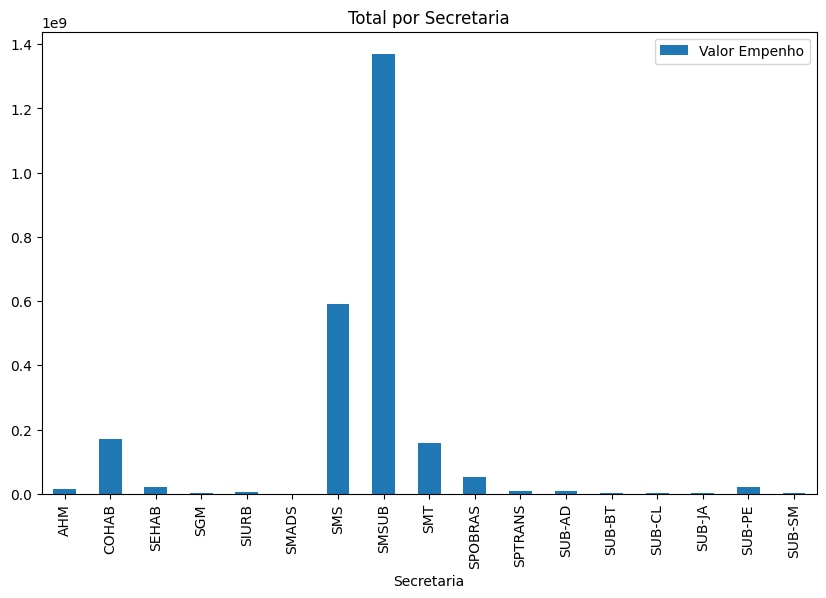

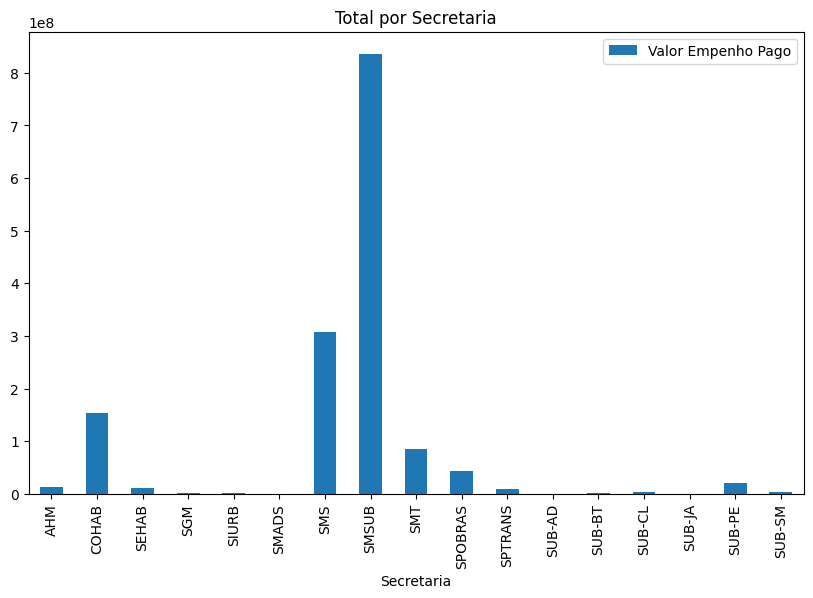

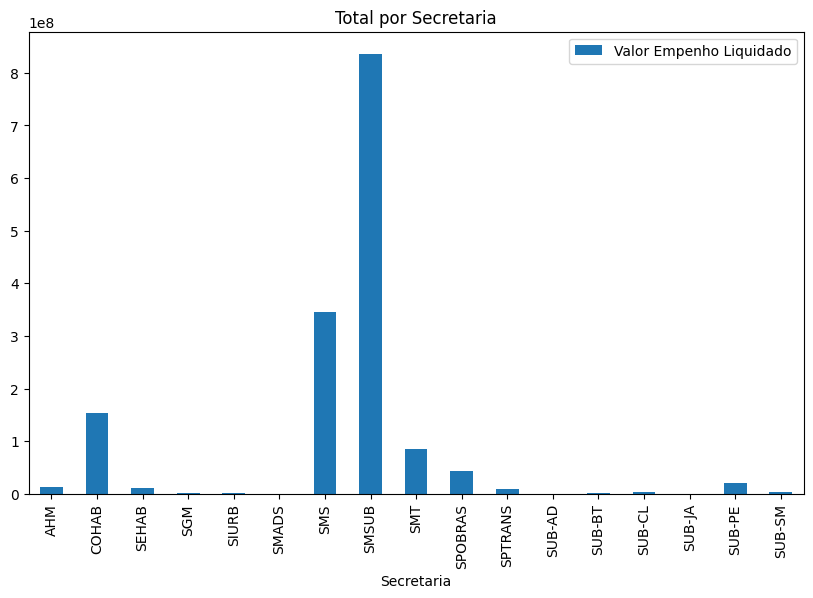

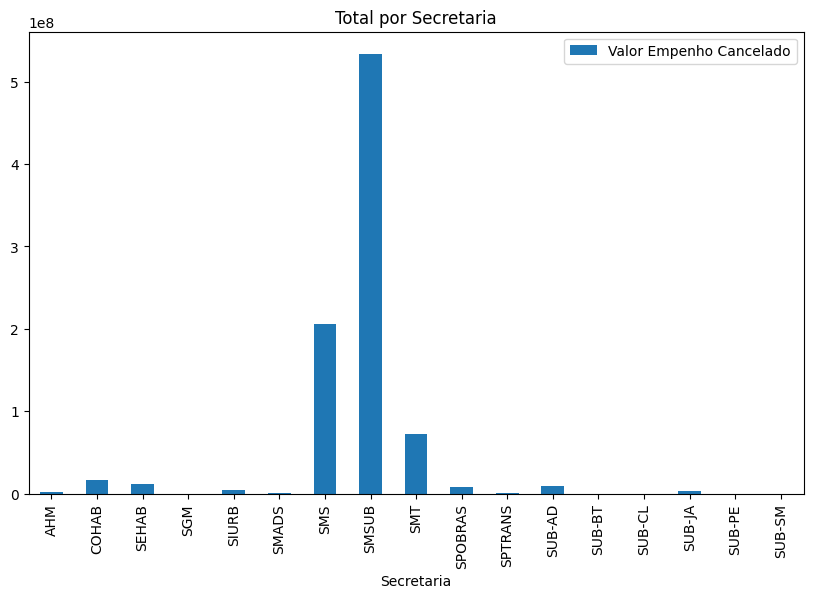

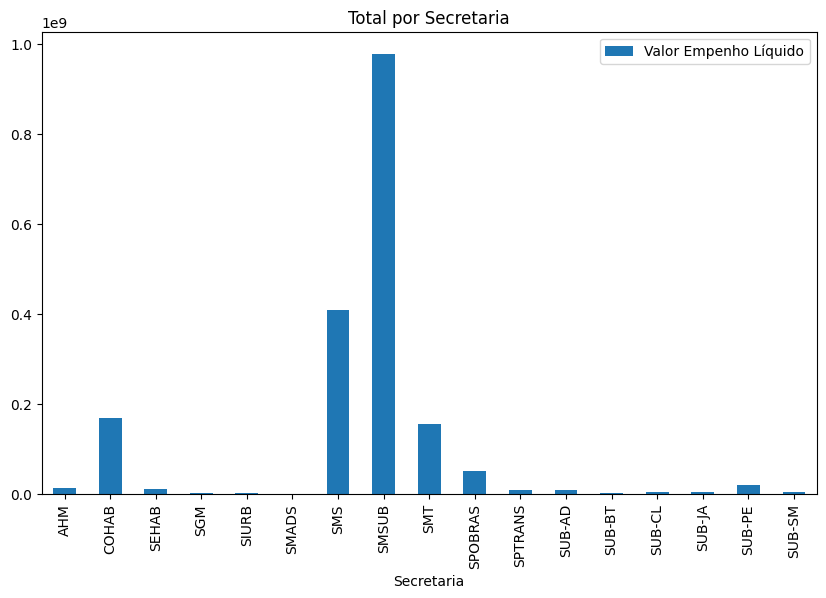

In [ ]:
totalsecretarias = geral.groupby('Secretaria')[['Valor Empenho','Valor Empenho Pago','Valor Empenho Liquidado','Valor Empenho Cancelado','Valor Empenho Líquido']].sum().reset_index()
for col in ['Valor Empenho', 'Valor Empenho Pago', 'Valor Empenho Liquidado', 'Valor Empenho Cancelado', 'Valor Empenho Líquido']:
    totalsecretarias.plot(kind='bar', x='Secretaria', y=col, title='Total por Secretaria', figsize=(10, 6))

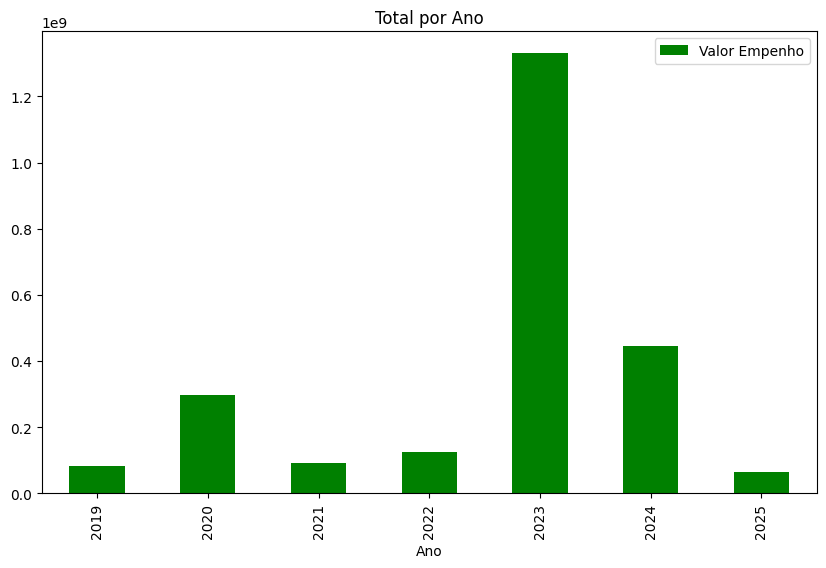

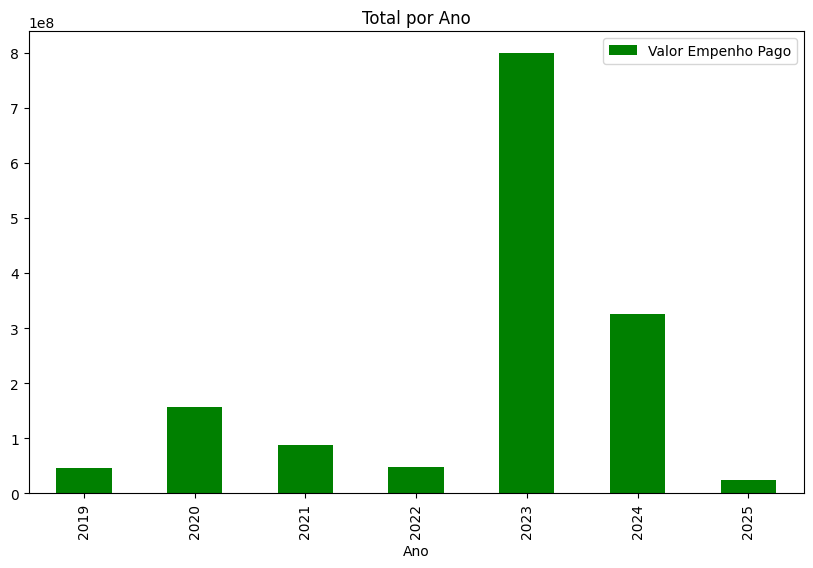

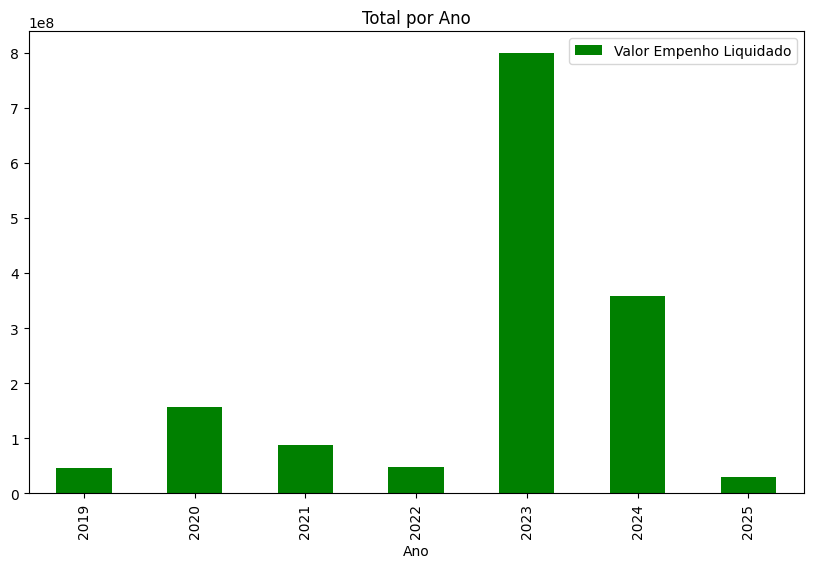

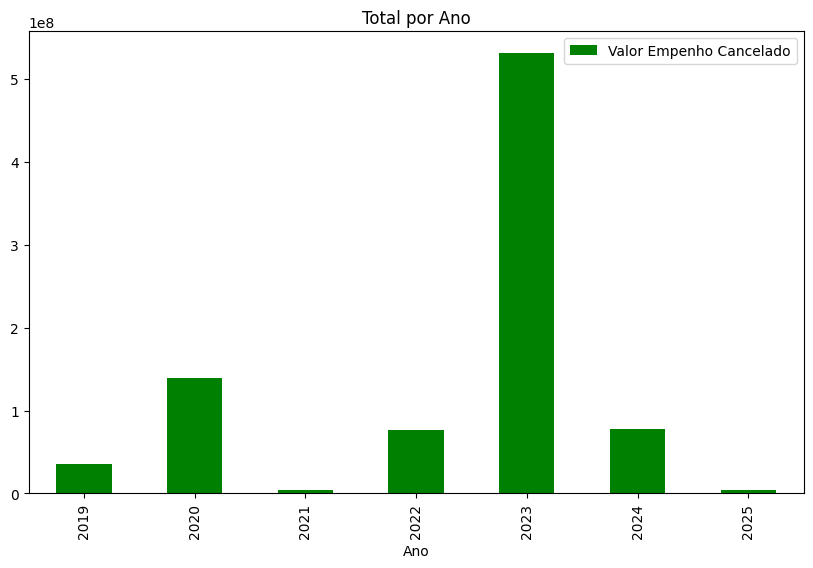

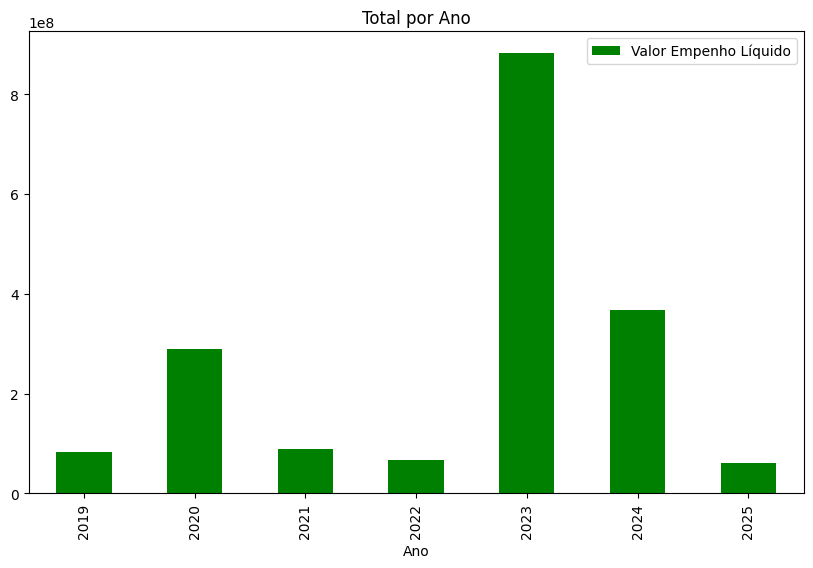

In [ ]:
totalanual = geral.groupby('Ano')[['Valor Empenho','Valor Empenho Pago','Valor Empenho Liquidado','Valor Empenho Cancelado','Valor Empenho Líquido']].sum().reset_index()
for col in ['Valor Empenho', 'Valor Empenho Pago', 'Valor Empenho Liquidado', 'Valor Empenho Cancelado', 'Valor Empenho Líquido']:
    totalanual.plot(kind='bar', x='Ano', y=col, title='Total por Ano', figsize=(10, 6), color='green')

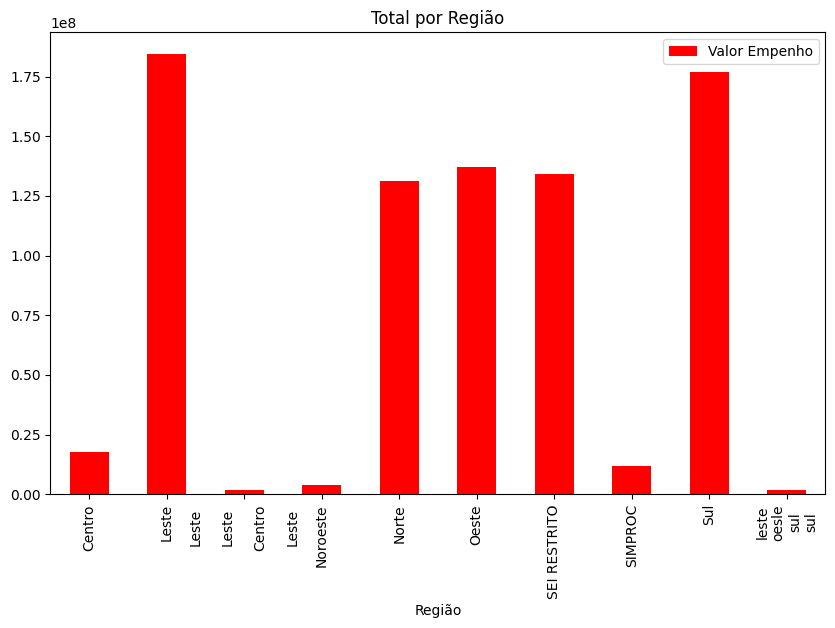

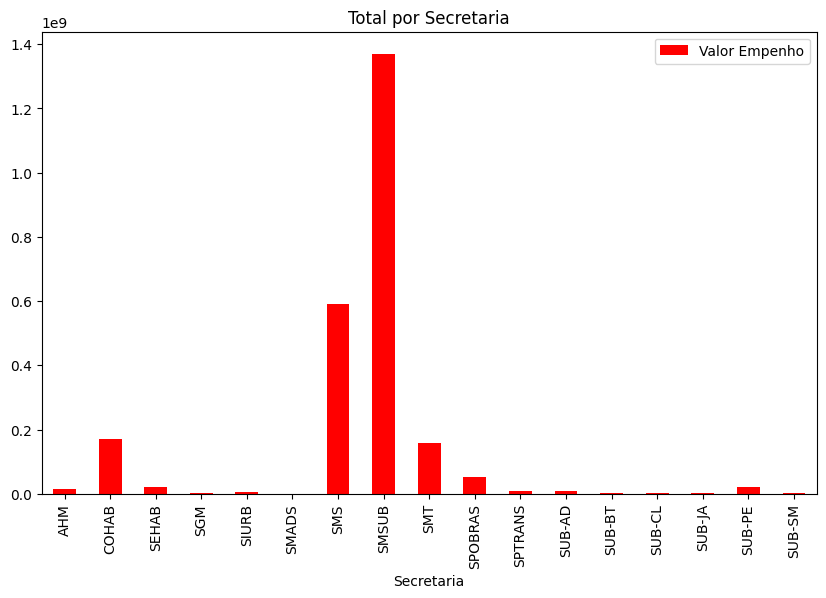

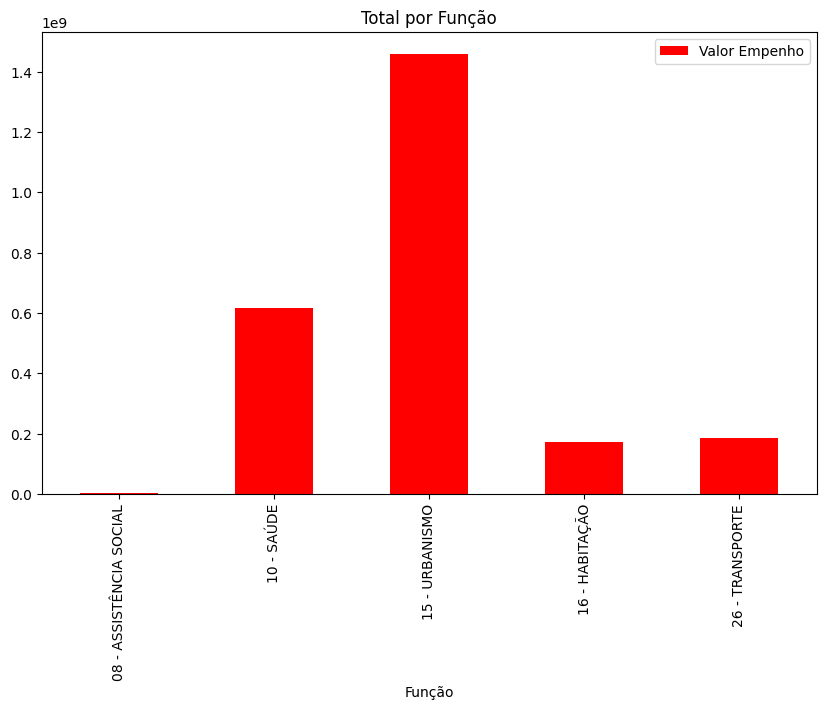

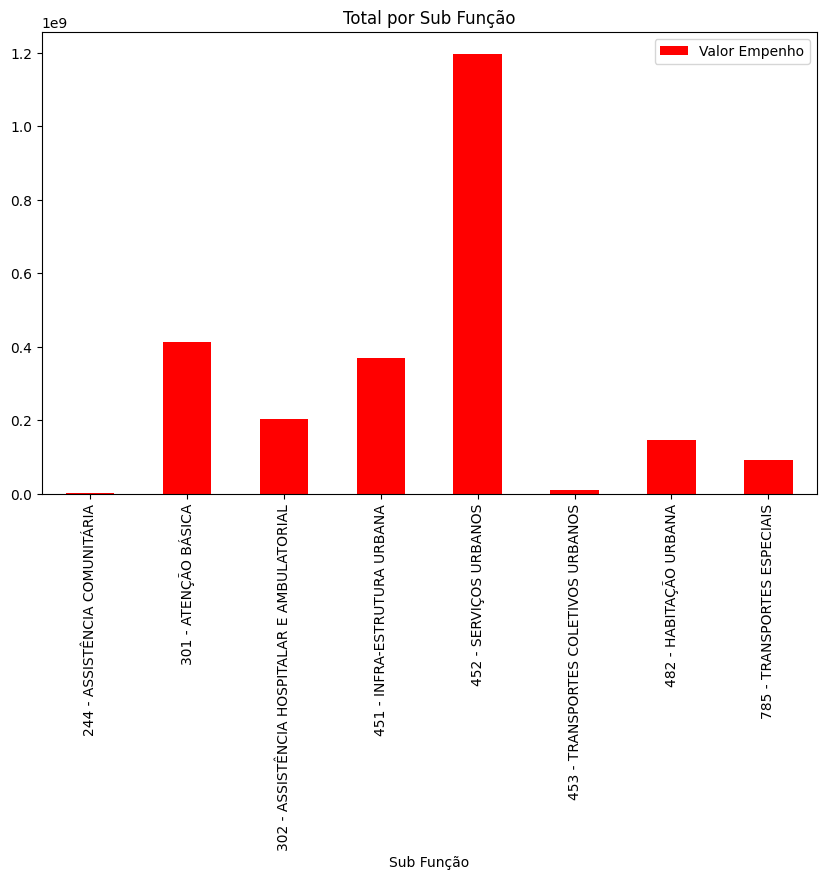

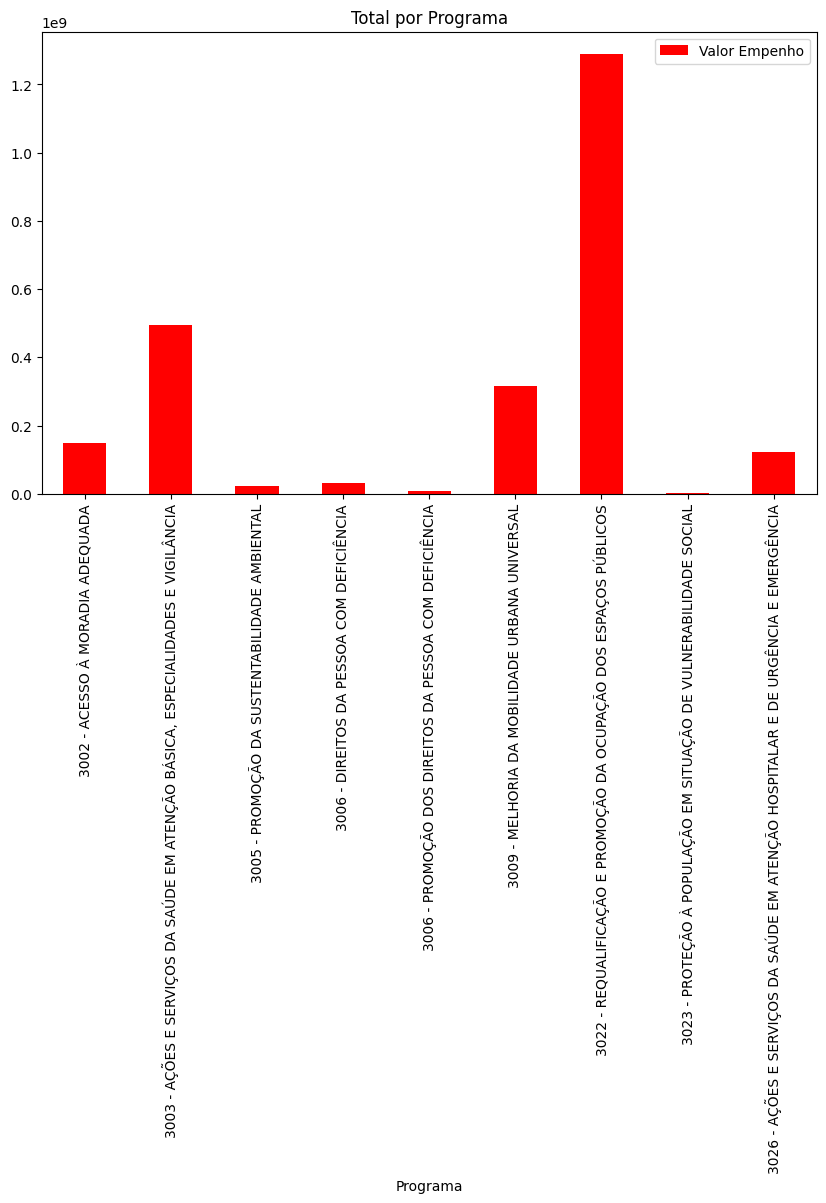

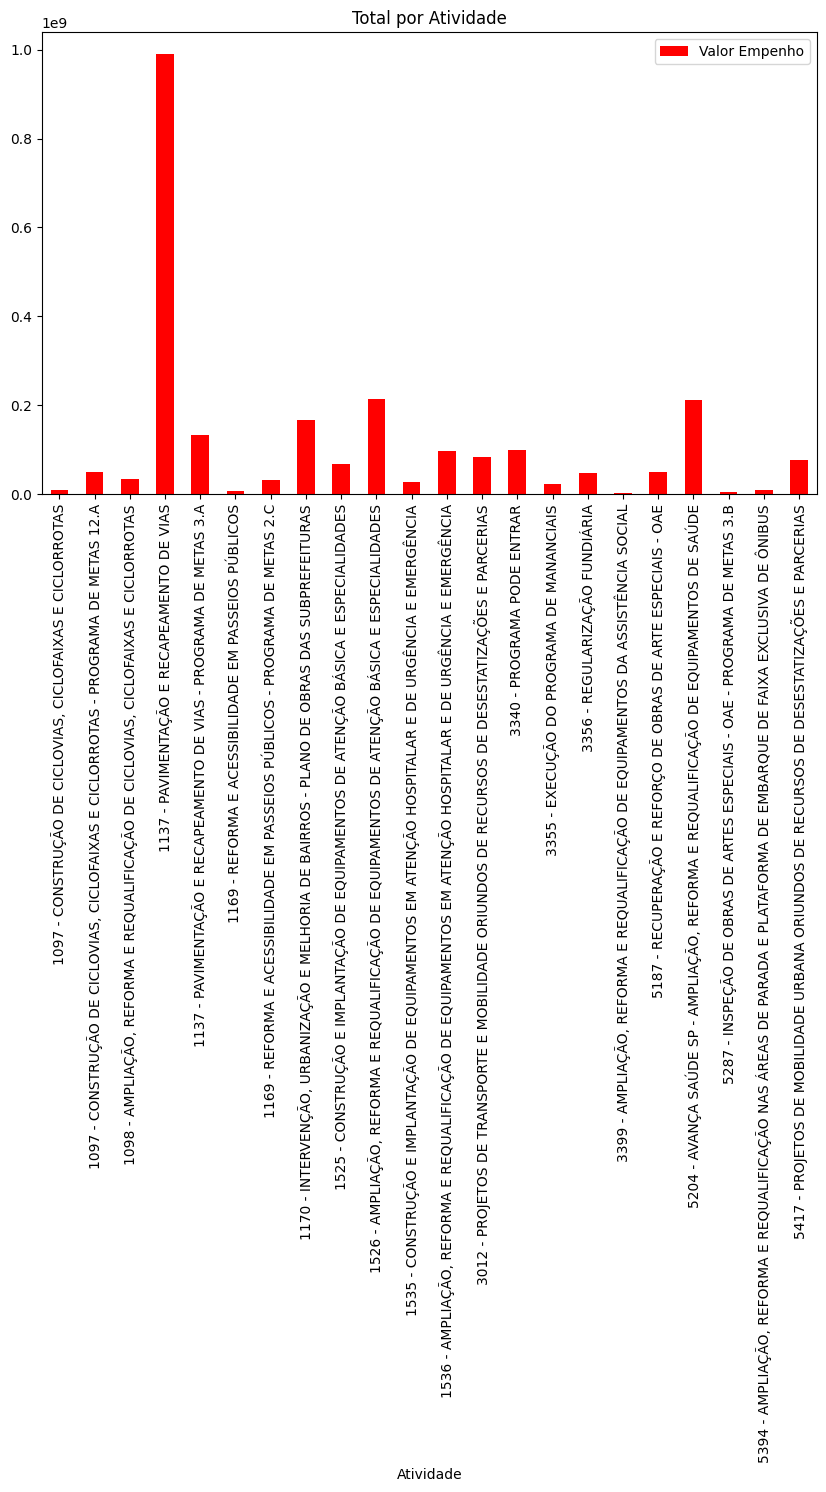

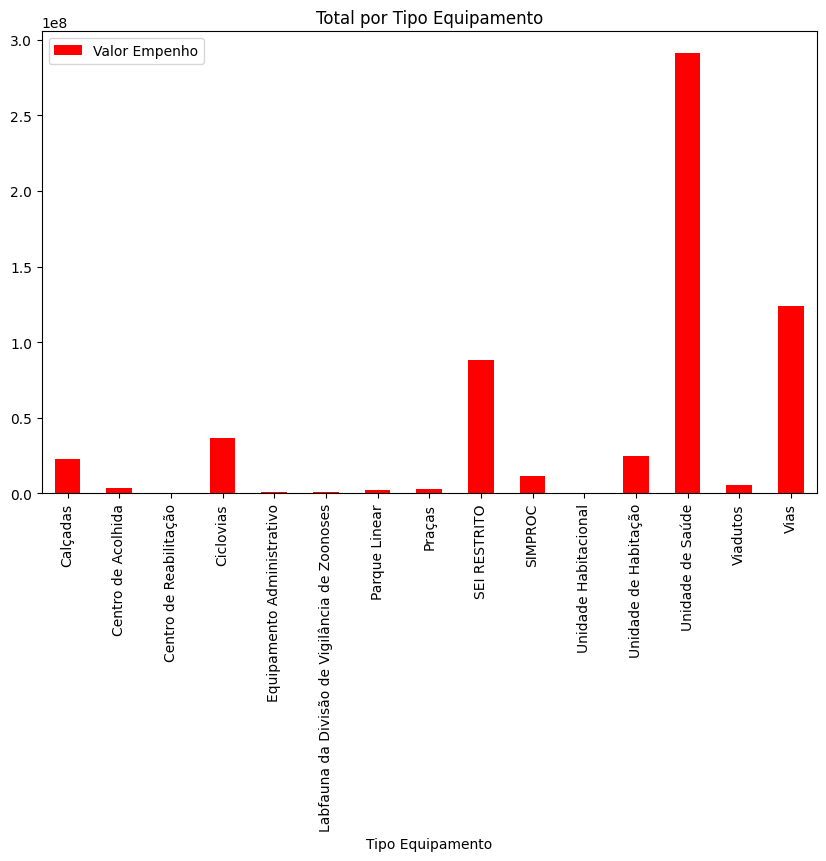

In [ ]:
lista = ['Região','Secretaria','Função','Sub Função','Programa','Atividade','Tipo Equipamento']
for i in lista:
    totalregiao = geral.groupby(i)['Valor Empenho'].sum().reset_index()
    totalregiao.plot(kind='bar', x=i, y='Valor Empenho', title=f'Total por {i}', figsize=(10, 6), color='red')

<Axes: title={'center': 'Total por Indice de Vulnerabilidade (só com geo)'}, xlabel='IPVS'>

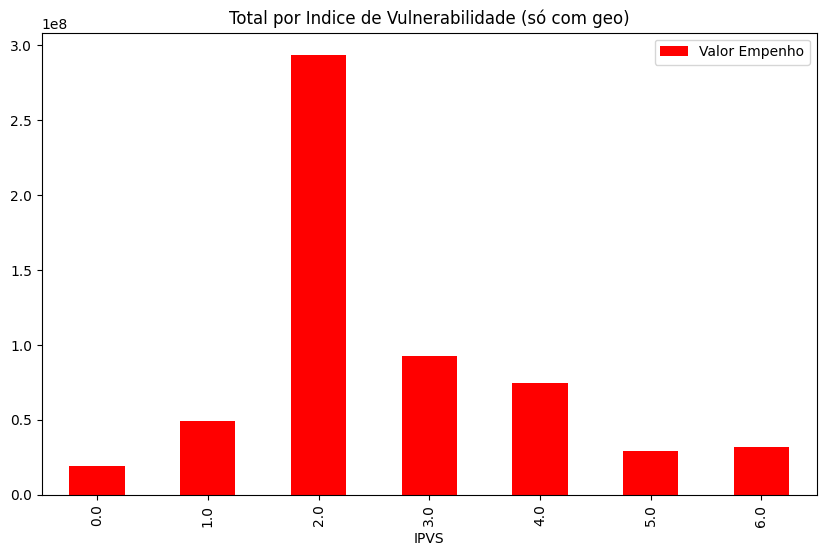

In [ ]:
totalipvs= pontos.groupby('IPVS')['Valor Empenho'].sum().reset_index()
totalipvs.plot(kind='bar', x='IPVS', y='Valor Empenho', title='Total por Indice de Vulnerabilidade (só com geo)', figsize=(10, 6), color='red')

In [ ]:
totalregiao = geral.groupby('Região')['Valor Empenho'].sum().reset_index()
totalregiao.plot(kind='bar', x='Região', y='Valor Empenho', title='Total por Região', figsize=(10, 6), color='red')

In [231]:
pontos

,Ano,Nota Empenho,Nota Reserva,Ata CMDP,Processo SEI,Secretaria,Função,Sub Função,Programa,Atividade,...,lat,lon,geometry,SubPrefeitura_left,Distrito_left,IPVS,Vulnerabilidade,SubPrefeitura_right,Distrito_right,radius
0,2019,83174/2019,55487/2019,13/06/2019,6012.2019/0005553-0,SMSUB,26 - TRANSPORTE,451 - INFRA-ESTRUTURA URBANA,3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL,3012 - PROJETOS DE TRANSPORTE E MOBILIDADE ORI...,...,-23.510306,-46.429360,POINT (-46.42936 -23.51031),ITAIM PAULISTA,VILA CURUCA,3.0,3- Vulnerabilidade baixa,ITAIM PAULISTA,VILA CURUCA,7.403601
1,2019,83190/2019,55487/2019,13/06/2019,6012.2019/0005554-8,SMSUB,26 - TRANSPORTE,451 - INFRA-ESTRUTURA URBANA,3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL,3012 - PROJETOS DE TRANSPORTE E MOBILIDADE ORI...,...,-23.543042,-46.420765,POINT (-46.42076 -23.54304),GUAIANASES,GUAIANASES,4.0,4- Vulnerabilidade média,GUAIANASES,GUAIANASES,9.683207
2,2019,83190/2019,55487/2019,13/06/2019,6012.2019/0005554-8,SMSUB,26 - TRANSPORTE,451 - INFRA-ESTRUTURA URBANA,3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL,3012 - PROJETOS DE TRANSPORTE E MOBILIDADE ORI...,...,-23.530408,-46.444058,POINT (-46.44406 -23.53041),ITAQUERA,ITAQUERA,2.0,2- Vulnerabilidade muito baixa,ITAQUERA,ITAQUERA,5.000000
3,2019,83190/2019,55487/2019,13/06/2019,6012.2019/0005554-8,SMSUB,26 - TRANSPORTE,451 - INFRA-ESTRUTURA URBANA,3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL,3012 - PROJETOS DE TRANSPORTE E MOBILIDADE ORI...,...,-23.539110,-46.414360,POINT (-46.41436 -23.53911),GUAIANASES,LAJEADO,2.0,2- Vulnerabilidade muito baixa,GUAIANASES,LAJEADO,5.000000
4,2019,83192/2019,55487/2019,13/06/2019,6012.2019/0005555-6,SMSUB,26 - TRANSPORTE,451 - INFRA-ESTRUTURA URBANA,3009 - MELHORIA DA MOBILIDADE URBANA UNIVERSAL,3012 - PROJETOS DE TRANSPORTE E MOBILIDADE ORI...,...,-23.588706,-46.544902,POINT (-46.5449 -23.58871),VILA PRUDENTE,SAO LUCAS,2.0,2- Vulnerabilidade muito baixa,VILA PRUDENTE,SAO LUCAS,9.665558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1481,2024,98940/2024,61174/2024,NaN,6018.2024/0068661-2,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"1526 - AMPLIAÇÃO, REFORMA E REQUALIFICAÇÃO DE ...",...,-23.464983,-46.604991,POINT (-46.60499 -23.46498),SANTANA-TUCURUVI,TUCURUVI,2.0,2- Vulnerabilidade muito baixa,SANTANA-TUCURUVI,TUCURUVI,5.634166
1482,2024,98952/2024,61165/2024,NaN,6018.2024/0062420-0,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"1526 - AMPLIAÇÃO, REFORMA E REQUALIFICAÇÃO DE ...",...,-23.591491,-46.752281,POINT (-46.75228 -23.59149),BUTANTA,VILA SONIA,6.0,6- Vulnerabilidade muito alta (aglomerados sub...,BUTANTA,VILA SONIA,6.408501
1483,2024,99145/2024,61184/2024,NaN,6018.2024/0057330-3,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"1526 - AMPLIAÇÃO, REFORMA E REQUALIFICAÇÃO DE ...",...,-23.433078,-46.743456,POINT (-46.74346 -23.43308),PIRITUBA-JARAGUA,JARAGUA,0.0,Sem Classificação,PIRITUBA-JARAGUA,JARAGUA,6.064241
1484,2024,99818/2024,61128/2024,NaN,6018.2024/0062072-7,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"1526 - AMPLIAÇÃO, REFORMA E REQUALIFICAÇÃO DE ...",...,-23.494294,-46.400526,POINT (-46.40053 -23.49429),ITAIM PAULISTA,ITAIM PAULISTA,4.0,4- Vulnerabilidade média,ITAIM PAULISTA,ITAIM PAULISTA,6.105307


In [ ]:
geral['Valor Empenho'].groupby(geral['Ano']).sum()

Ano
2019    8.265735e+07
2020    2.961164e+08
2021    9.211079e+07
2022    1.243667e+08
2023    1.329454e+09
2024    4.445552e+08
2025    6.568835e+07
Name: Valor Empenho, dtype: float64

In [ ]:
# # geral['Valor Empenho'].groupby(geral['Ano']).sum().plot(kind='bar', title='Valores empenhados por Ano (em Bilhões de Reais)', figsize=(20, 3), color='blue')
# #Gráfico de Barras com Plotly
# fig = px.bar(geral, x='Ano', y='Valor Empenho', title='Valores empenhados por Ano (R$)', labels='Valor Empenho')
# fig.show()

In [ ]:
# Configurar o locale para português do Brasil (ou outro que use vírgula para decimal)
# Isso é essencial para a formatação de moeda.
# 'pt_BR.UTF-8' é comum em Linux/macOS. Em Windows, pode ser 'Portuguese_Brazil' ou 'pt_BR'.
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except locale.Error:
    # Se o locale não for encontrado, tenta uma alternativa para Windows
    try:
        locale.setlocale(locale.LC_ALL, 'Portuguese_Brazil')
    except locale.Error:
        print("Aviso: Não foi possível configurar o locale pt_BR. A formatação pode não ser a esperada.")
        # Fallback: Se o locale não for setado, a formatação manual abaixo ainda funciona, mas é menos robusta.


In [ ]:
geral['Valor Empenho Formatado'] = geral['Valor Empenho'].apply(
    lambda x: f"R$ {x:,.2f}".replace(",", "TEMP_COMMA").replace(".", ",").replace("TEMP_COMMA", ".")
)

In [ ]:
geral['Valor Formatado'] = geral['Valor Empenho'].apply(
    lambda x: 'R$ ' + locale.format_string("%.2f", x, grouping=True)
)

In [ ]:
# 1. Agrupar os dados por 'Ano' e somar 'Valor Empenho'
df_total_por_ano = geral.groupby('Ano')['Valor Empenho'].sum().reset_index()

# 2. Configurar o locale para português do Brasil (ou outro que use vírgula para decimal)
# Isso é essencial para a formatação de moeda.
# 'pt_BR.UTF-8' é comum em Linux/macOS. Em Windows, pode ser 'Portuguese_Brazil' ou 'pt_BR'.
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except locale.Error:
    # Se o locale não for encontrado, tenta uma alternativa para Windows
    try:
        locale.setlocale(locale.LC_ALL, 'Portuguese_Brazil')
    except locale.Error:
        print("Aviso: Não foi possível configurar o locale pt_BR. A formatação pode não ser a esperada.")
        # Fallback: Se o locale não for setado, a formatação manual abaixo ainda funciona, mas é menos robusta.

# 3. Criar uma nova coluna com os valores formatados como string (R$ 1.234,56)
# Usamos map com uma função lambda para aplicar a formatação
df_total_por_ano['Valor Formatado'] = df_total_por_ano['Valor Empenho'].apply(
    lambda x: 'R$ ' + locale.format_string("%.2f", x, grouping=True)
)
# Ou, uma forma mais direta se você não quer o locale para tudo, mas só para o valor:
# df_total_por_ano['Valor Formatado'] = df_total_por_ano['Valor Empenho'].apply(
#     lambda x: f"R$ {x:,.2f}".replace(",", "TEMP_COMMA").replace(".", ",").replace("TEMP_COMMA", ".")
# )


# 4. Criar o gráfico de barras com Plotly Express
fig = px.bar(
    df_total_por_ano,
    x='Ano',
    y='Valor Empenho',
    title='Valores Empenhados por Ano (R$)',
    labels={'Valor Empenho': 'Valor Total Empenhado'},
    text='Valor Formatado' # Use a nova coluna formatada para o texto
)

# Ajuste a posição do texto, se necessário.
# Não precisamos de texttemplate aqui, pois o texto já está formatado.
fig.update_traces(textposition='outside')

# 5. Melhorar a exibição do eixo Y para valores monetários com formatação brasileira
fig.update_yaxes(
    tickprefix='R$ '
)


fig.show()

In [ ]:
# pontos['Valor Empenho'].groupby(pontos['Ano']).sum().plot(kind='bar', title='Valores empenhados por Ano (em Centenas de Milhões de Reais) (somente pontos com geolocalização)', figsize=(20, 3), color='red')

# Criar o gráfico de barras com Plotly Express
fig = px.bar(
    pontos.groupby('Ano')['Valor Empenho'].sum().reset_index(),
    x='Ano',
    y='Valor Empenho',
    title='Valores Empenhados por Ano (R$)[para pontos com geolocalização]',
    labels={'Valor Empenho': 'Valor Total Empenhado'},
    text='Valor Empenho' # Esta linha adiciona os rótulos de texto
)

# Opcional: Ajustar a formatação do texto nos rótulos (por exemplo, para exibir em R$)
fig.update_traces(texttemplate='R$ %{y:,.2f}', textposition='outside')

# Opcional: Melhorar a exibição do eixo Y para valores monetários
fig.update_yaxes(tickprefix='R$ ')

fig.show()

In [ ]:
#Percentual de valores de empenhos geolocalizados
total_empenhos = geral['Valor Empenho'].sum()
total_empenhos_geolocalizados = pontos['Valor Empenho'].sum()
percentual_geolocalizados = (total_empenhos_geolocalizados / total_empenhos) * 100
print(f"Percentual de valores com empenhos já geolocalizados: {percentual_geolocalizados:.2f}%")

#Percentual de pontos com empenhos geolocalizados
total_pontos = len(pontos)
total_geral = len(geral)
percentual_pontos_geolocalizados = (total_pontos / total_geral) * 100
print(f"Percentual de pontos com empenhos geolocalizados: {percentual_pontos_geolocalizados:.2f}%")

Percentual de valores com empenhos já geolocalizados: 25.13%
Percentual de pontos com empenhos geolocalizados: 32.04%


In [ ]:
popula = pd.read_excel('Popula_SP_2022.xlsx')
popula['Pop Total 2022'].sum()

np.int64(11451999)

<Axes: title={'center': 'Quantidade de população por Distrito (IBGE - 2022)'}, xlabel='Distrito'>

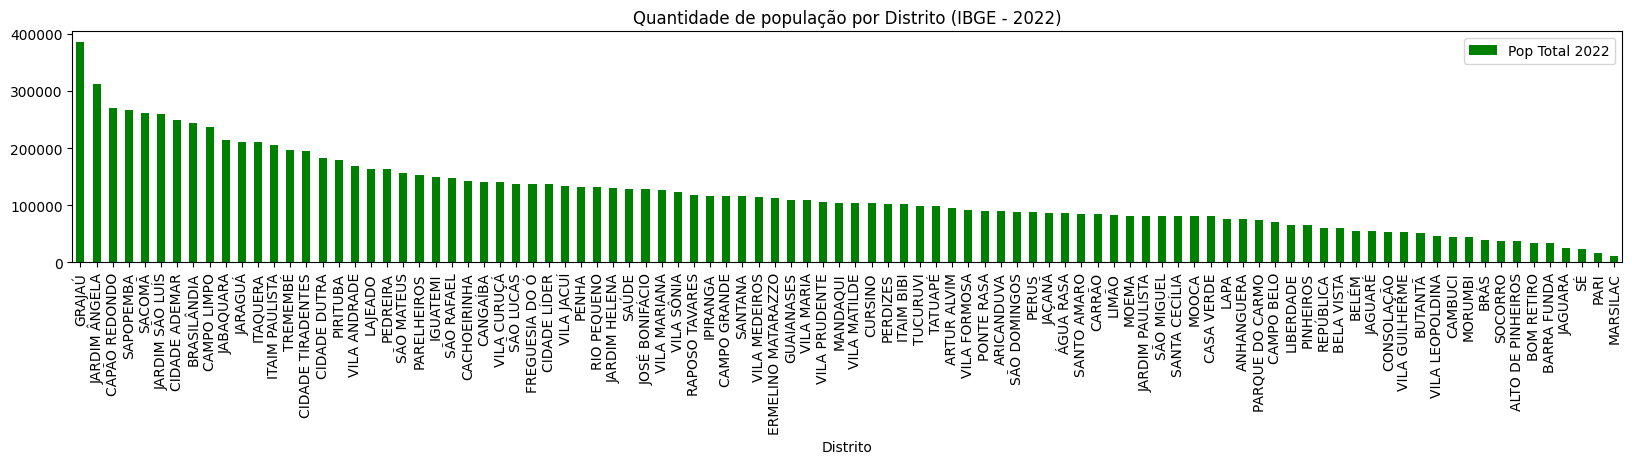

In [ ]:
#Exibe a quantidade de População por Distrito
popula.sort_values(by='Pop Total 2022', ascending=False, inplace=True)
popula.plot(kind='bar', title='Quantidade de população por Distrito (IBGE - 2022)',x='Distrito' ,y='Pop Total 2022', figsize=(20, 3), color='green')
# popdist.plot(kind='bar', title='Quantidade de população por Distrito (IBGE - 2022)', figsize=(20, 3), color='green')

<Axes: title={'center': 'Quantidade de Empenhos por Distrito (somente pontos com geolocalização)'}, xlabel='Distrito_right'>

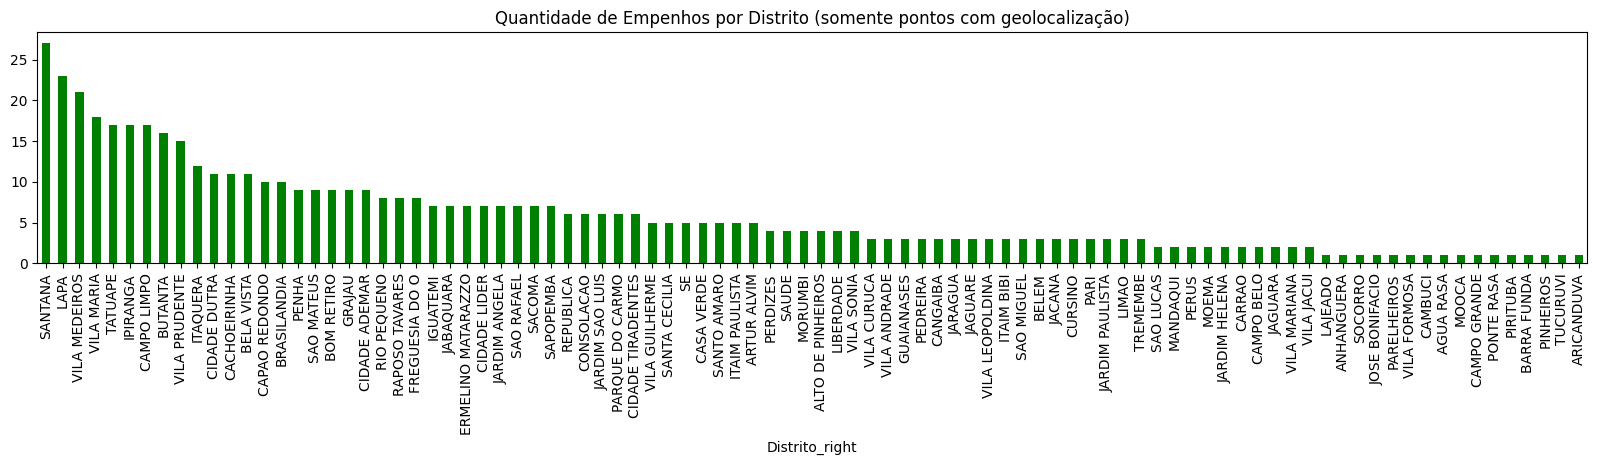

In [ ]:
#Exibe a quantidade de empenhos por Distrito
cadadist = pontos['Distrito_right'].value_counts()
cadadist.plot(kind='bar', title='Quantidade de Empenhos por Distrito (somente pontos com geolocalização)', figsize=(20, 3), color='green')

<Axes: title={'center': 'Quantidade de Empenhos por Subprefeitura (somente pontos com geolocalização)'}, xlabel='SubPrefeitura_right'>

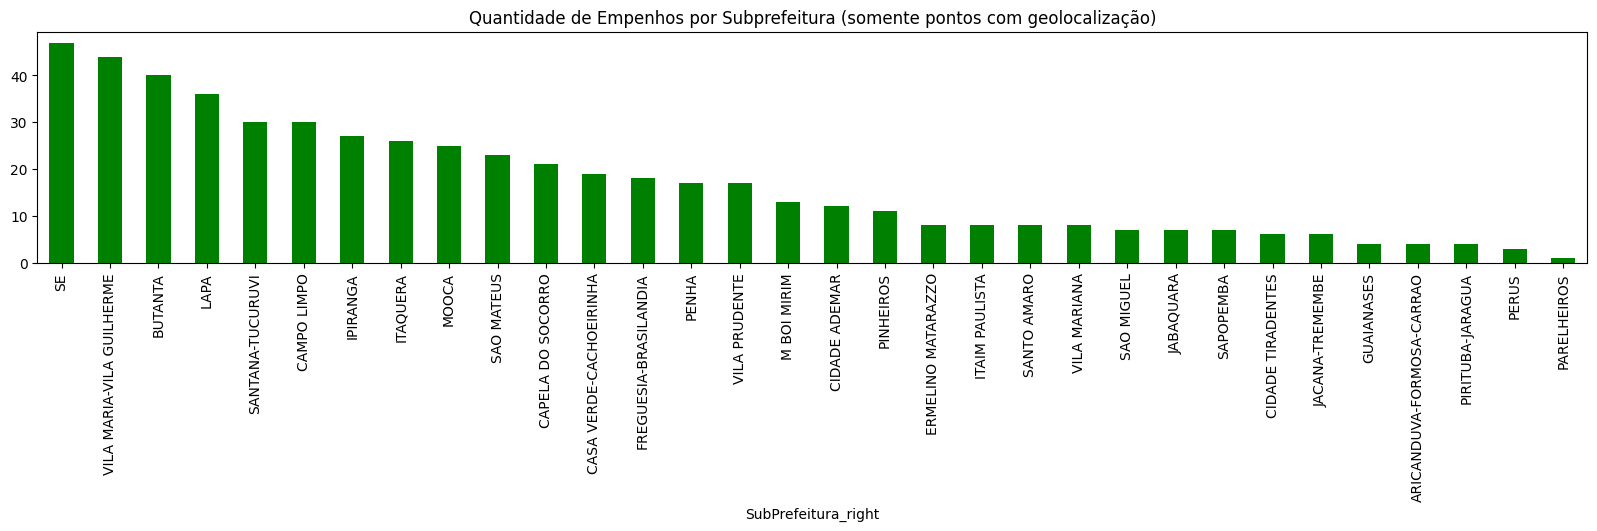

In [ ]:
#Exibe a quantidade de Empenhos por Subprefeitura
cadasub = pontos['SubPrefeitura_right'].value_counts()
cadasub.plot(kind='bar', title='Quantidade de Empenhos por Subprefeitura (somente pontos com geolocalização)', figsize=(20, 3), color='green')

<Axes: title={'center': 'Valores empenhados por Distrito (em Dezenas de Milhões de Reais) (somente pontos com geolocalização)'}, xlabel='Distrito_right'>

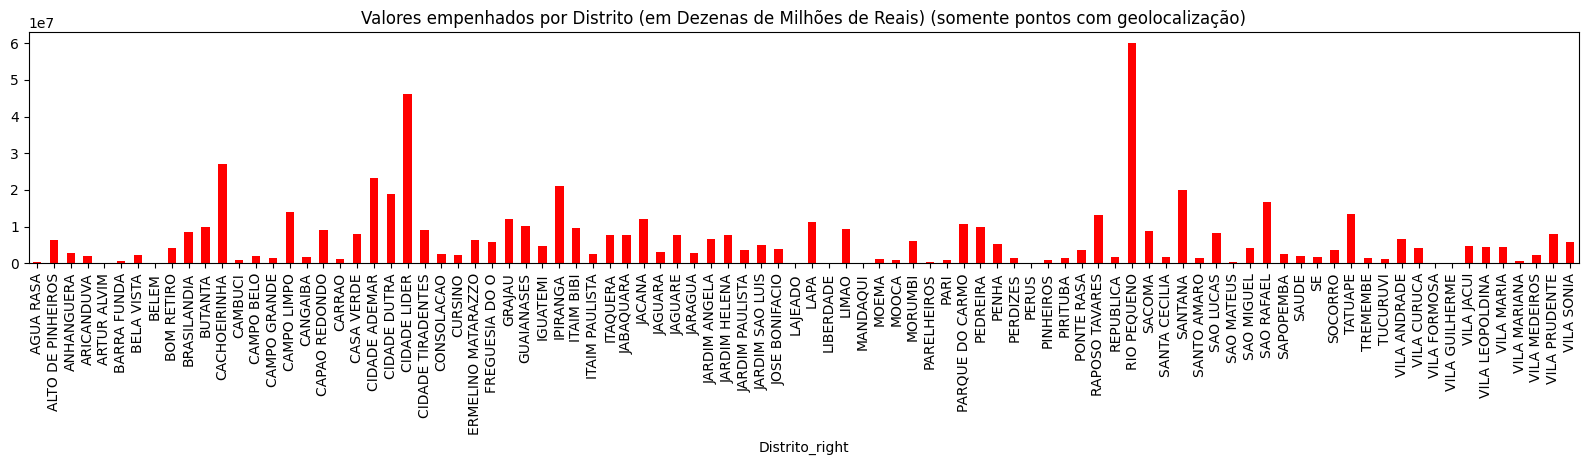

In [ ]:
pontos['Valor Empenho'].groupby(pontos['Distrito_right']).sum().plot(kind='bar', title='Valores empenhados por Distrito (em Dezenas de Milhões de Reais) (somente pontos com geolocalização)', figsize=(20, 3), color='red')

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Suponha que 'popula' tenha colunas: ['Distrito', 'Pop Total 2022']
# # E que 'pontos' seja um DataFrame com uma coluna 'Distrito'

# # Crie o segundo DataFrame com a contagem de empenhos por distrito
# cadadist = pontos['Distrito'].value_counts().reset_index()
# cadadist.columns = ['Distrito', 'Empenhos']

# # Combine os dois DataFrames usando a coluna 'Distrito' como chave
# df_merged = pd.merge(popula, cadadist, on='Distrito')

# # Ordena os dados pelo total da população para manter a ordem
# df_merged.sort_values(by='Pop Total 2022', ascending=False, inplace=True)

# # Define a posição de cada distrito no eixo X
# x = range(len(df_merged))

# # Define a largura de cada barra
# bar_width = 0.4

# # Cria a figura
# plt.figure(figsize=(20, 5))

# # Barras de população
# plt.bar(x, df_merged['Pop Total 2022'], width=bar_width, label='População 2022', color='green')

# # Barras de empenhos, deslocadas para a direita
# plt.bar([i + bar_width for i in x], df_merged['Empenhos'], width=bar_width, label='Empenhos', color='orange')

# # Coloca os nomes dos distritos no eixo X no meio das duas barras
# plt.xticks([i + bar_width / 2 for i in x], df_merged['Distrito'], rotation=90)

# # Adiciona título e legenda
# plt.title('População vs. Empenhos por Distrito')
# plt.xlabel('Distrito')
# plt.ylabel('Quantidade')
# plt.legend()

# plt.tight_layout()
# plt.show()


In [ ]:
# Criar o gráfico de barras com Plotly Express
fig = px.bar(
    pontos.groupby('Secretaria')['Valor Empenho'].sum().reset_index(),
    x='Secretaria',
    y='Valor Empenho',
    title='Valores Empenhados por Secretaria (R$)[para pontos com geolocalização]',
    labels={'Valor Empenho': 'Valor Total Empenhado'},
    text='Valor Empenho' # Esta linha adiciona os rótulos de texto
)

# Opcional: Ajustar a formatação do texto nos rótulos (por exemplo, para exibir em R$)
fig.update_traces(texttemplate='R$ %{y:,.2f}', textposition='outside')

# Opcional: Melhorar a exibição do eixo Y para valores monetários
fig.update_yaxes(tickprefix='R$ ')

fig.show()

In [ ]:
# Criar o gráfico de barras com Plotly Express
fig = px.bar(
    geral.groupby('Secretaria')['Valor Empenho'].sum().reset_index(),
    x='Secretaria',
    y='Valor Empenho',
    title='Valores Empenhados por Secretaria (R$)',
    labels={'Valor Empenho': 'Valor Total Empenhado'},
    text='Valor Empenho' # Esta linha adiciona os rótulos de texto
)

# Opcional: Ajustar a formatação do texto nos rótulos (por exemplo, para exibir em R$)
fig.update_traces(texttemplate='R$ %{y:,.2f}', textposition='outside')

# Opcional: Melhorar a exibição do eixo Y para valores monetários
fig.update_yaxes(tickprefix='R$ ')

fig.show()

In [ ]:
invbydis = pontos['Valor Empenho'].groupby(pontos['Distrito_right']).sum()

In [ ]:
correlacao = invbydis.corr(popula['Pop Total 2022'])
print(correlacao)

nan


In [ ]:
popula

,Distrito,Pop Total 2022,Pop Urb 2022,Pop Rur 2022
29,GRAJAÚ,384873,382897,1976
41,JARDIM ÂNGELA,311432,311329,103
18,CAPÃO REDONDO,270767,270767,0
77,SAPOPEMBA,266715,266715,0
68,SACOMÃ,261436,261436,0
...,...,...,...,...
5,BARRA FUNDA,33436,33436,0
38,JAGUARA,24730,24730,0
79,SÉ,23832,23832,0
56,PARI,17359,17359,0


In [ ]:
invbydis

Distrito
AGUA RASA             468922.74
ALTO DE PINHEIROS    6339256.76
ANHANGUERA           2817216.11
ARICANDUVA           1980753.86
ARTUR ALVIM            10607.04
                        ...    
VILA MARIA           4507652.58
VILA MARIANA          556115.79
VILA MEDEIROS        2365362.21
VILA PRUDENTE        7986366.53
VILA SONIA           5775685.69
Name: Valor Empenho, Length: 92, dtype: float64

In [ ]:
# import plotly.graph_objects as go

# fig = go.Figure()
# fig.add_trace(go.Bar(x=pontos['Distrito'], y=popula['Pop Total 2022'], name='População'))


# fig.update_layout(barmode='group', title='População vs Investimento por Região')
# fig.show()

In [ ]:
# fig = go.Figure()
# fig.add_trace(go.Bar(x=pontos['Distrito'], y=invbydis['Valor Empenho'], name='Investimento'))
# fig.update_layout(barmode='group', title='População vs Investimento por Região')
# fig.show()